# 🛡️ NetSentinel — App Fingerprinting from Encrypted Traffic
## Training Notebook

**Goal:** Identify which app (Netflix, YouTube, Instagram, etc.) generated network traffic using only packet metadata — without decrypting anything.

**Approach:** Inspired by PACKETPRINT (NDSS 2022), we use packet size sequences, inter-arrival times, burst patterns, and flow statistics to fingerprint apps.

**Models:** XGBoost + 1D-CNN

---

## 1. Setup

In [28]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import glob
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier
import joblib


## 2. Load Dataset

Our dataset was collected using NetSentinel's traffic collector. Each CSV contains sliding-window samples (5s windows, 2s step) from a single app session. Features include packet size statistics, inter-arrival times, burst patterns, direction ratios, and raw packet size sequences (PSS).

In [29]:
# Load all CSVs from the app_traffic directory
# Update this path to where your CSV files are
DATA_DIR = '../data_v3/app_traffic'  # Change if needed

csv_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
print(f'Found {len(csv_files)} CSV files:\n')

dfs = []
for f in sorted(csv_files):
    df = pd.read_csv(f)
    app = os.path.basename(f).split('_')[0]
    df['app'] = app  # Ensure label is set from filename
    dfs.append(df)
    print(f'  {os.path.basename(f)}: {len(df)} samples (app: {app})')

df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal: {len(df)} samples across {df["app"].nunique()} apps')

Found 8 CSV files:

  meta_20260329_014605.csv: 787 samples (app: meta)
  netflix_20260329_012448.csv: 708 samples (app: netflix)
  vpn-meta_20260330_161850.csv: 798 samples (app: vpn-meta)
  vpn-netflix_20260330_162311.csv: 701 samples (app: vpn-netflix)
  vpn-spotify_20260330_161842.csv: 710 samples (app: vpn-spotify)
  vpn-youtube_20260330_164948.csv: 797 samples (app: vpn-youtube)
  vpn-zoom_20260330_161842.csv: 798 samples (app: vpn-zoom)
  zoom_20260329_020754.csv: 799 samples (app: zoom)

Total: 6098 samples across 8 apps


In [30]:
# Class distribution
print('=== Class Distribution ===')
print(df['app'].value_counts())

fig = px.bar(x=df['app'].value_counts().index, 
             y=df['app'].value_counts().values,
             title='Samples per App',
             labels={'x': 'App', 'y': 'Samples'},
             color=df['app'].value_counts().index,
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(height=400, showlegend=False)
fig.show()

=== Class Distribution ===
app
zoom           799
vpn-meta       798
vpn-zoom       798
vpn-youtube    797
meta           787
vpn-spotify    710
netflix        708
vpn-netflix    701
Name: count, dtype: int64


## 3. Exploratory Data Analysis

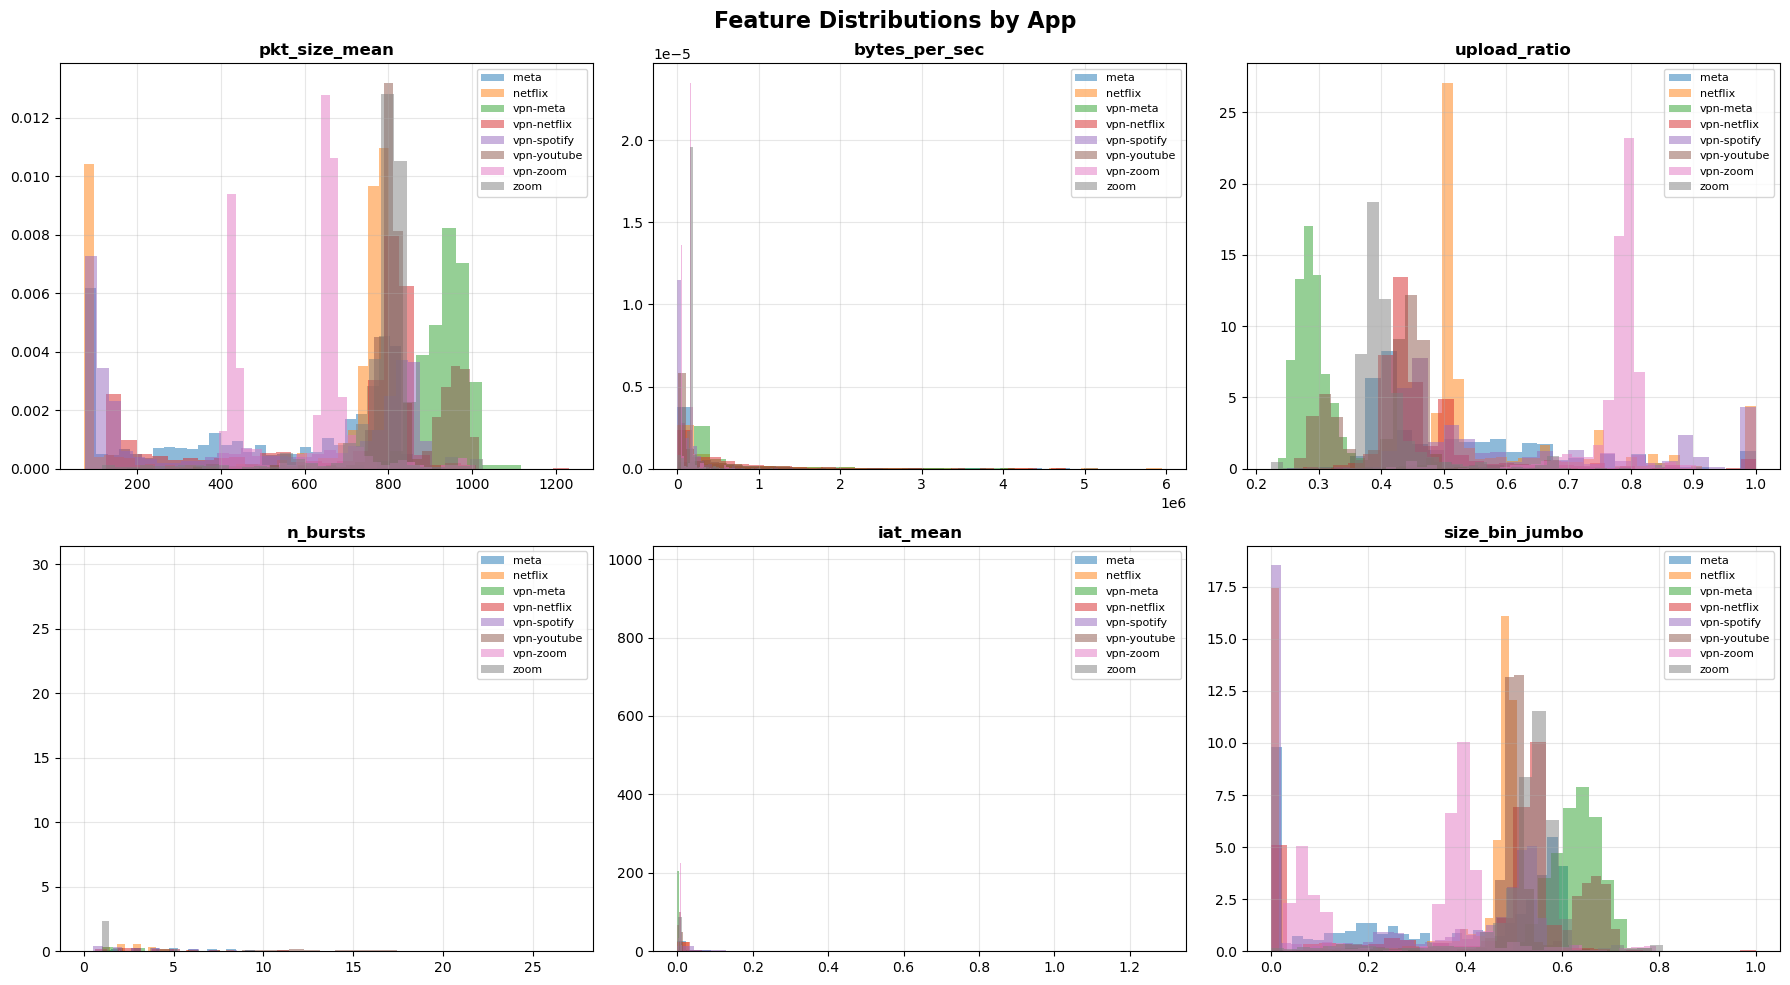

In [31]:
# 3.1 — Key feature distributions per app
key_features = ['pkt_size_mean', 'bytes_per_sec', 'upload_ratio', 
                'n_bursts', 'iat_mean', 'size_bin_jumbo']

# Only plot features that exist
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feat in enumerate(key_features):
    ax = axes[i//3][i%3]
    for app in df['app'].unique():
        subset = df[df['app'] == app][feat]
        ax.hist(subset, bins=30, alpha=0.5, label=app, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by App', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('app_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# 3.2 — QUIC ratio per app (great discriminator)
if 'quic_ratio' in df.columns:
    fig = px.box(df, x='app', y='quic_ratio', color='app',
                 title='QUIC Protocol Usage by App',
                 labels={'quic_ratio': 'QUIC Ratio', 'app': 'App'})
    fig.update_layout(height=400, showlegend=False)
    fig.show()

In [33]:
# 3.3 — Upload vs Download ratio scatter
fig = px.scatter(df, x='upload_ratio', y='bytes_per_sec', color='app',
                 title='Upload Ratio vs Bandwidth by App',
                 labels={'upload_ratio': 'Upload Ratio', 'bytes_per_sec': 'Bytes/sec'},
                 opacity=0.6)
fig.update_layout(height=500)
fig.show()

In [34]:
# 3.4 — App traffic fingerprint radar chart
radar_features = ['pkt_size_mean', 'bytes_per_sec', 'upload_ratio',
                  'n_bursts', 'iat_mean', 'size_bin_jumbo']
radar_features = [f for f in radar_features if f in df.columns]

fig = go.Figure()
for app in df['app'].unique():
    subset = df[df['app'] == app][radar_features].mean()
    # Normalize to 0-1 for radar
    normalized = (subset - df[radar_features].min()) / (df[radar_features].max() - df[radar_features].min() + 1e-8)
    fig.add_trace(go.Scatterpolar(
        r=normalized.values.tolist() + [normalized.values[0]],
        theta=radar_features + [radar_features[0]],
        name=app, fill='toself', opacity=0.6
    ))
fig.update_layout(title='App Traffic Fingerprint Profiles', height=500,
                  polar=dict(radialaxis=dict(visible=True, range=[0, 1])))
fig.show()

## 4. Feature Preparation

In [35]:
# 4.1 — Encode labels
le = LabelEncoder()
y = le.fit_transform(df['app'])
app_names = le.classes_
n_classes = len(app_names)

print(f'Classes ({n_classes}): {list(app_names)}')
print(f'Label mapping: {dict(zip(app_names, range(n_classes)))}')

Classes (8): ['meta', 'netflix', 'vpn-meta', 'vpn-netflix', 'vpn-spotify', 'vpn-youtube', 'vpn-zoom', 'zoom']
Label mapping: {'meta': 0, 'netflix': 1, 'vpn-meta': 2, 'vpn-netflix': 3, 'vpn-spotify': 4, 'vpn-youtube': 5, 'vpn-zoom': 6, 'zoom': 7}


In [36]:
# 4.2 — Statistical features (for XGBoost)
stat_features = [
    'window_duration', 'total_packets', 'total_bytes',
    'packets_per_sec', 'bytes_per_sec',
    'pkt_size_mean', 'pkt_size_std', 'pkt_size_min', 'pkt_size_max',
    'pkt_size_median', 'pkt_size_q25', 'pkt_size_q75', 'pkt_size_skew', 'pkt_size_iqr',
    'size_bin_tiny', 'size_bin_small', 'size_bin_medium', 'size_bin_large', 'size_bin_jumbo',
    'payload_mean', 'payload_std', 'payload_max', 'payload_zero_ratio', 'payload_total',
    'iat_mean', 'iat_std', 'iat_min', 'iat_max', 'iat_median', 'iat_q25', 'iat_q75',
    'upload_packets', 'download_packets', 'upload_ratio', 'download_ratio', 'up_down_ratio',
    'up_bytes_total', 'up_size_mean', 'up_size_std', 'up_size_max',
    'down_bytes_total', 'down_size_mean', 'down_size_std', 'down_size_max',
    'up_iat_mean', 'up_iat_std', 'down_iat_mean', 'down_iat_std',
    'n_bursts', 'avg_burst_size', 'max_burst_size', 'burst_ratio',
    'n_unique_dst_ports', 'tcp_ratio', 'udp_ratio',
]

# Add quic_ratio if available
if 'quic_ratio' in df.columns:
    stat_features.append('quic_ratio')

available_stat = [f for f in stat_features if f in df.columns]
X_stat = df[available_stat].fillna(0).replace([np.inf, -np.inf], 0)

scaler = StandardScaler()
X_stat_scaled = pd.DataFrame(scaler.fit_transform(X_stat), columns=X_stat.columns)

print(f'Statistical features: {len(available_stat)}')

Statistical features: 56


In [37]:
# 4.3 — Packet Size Sequences (for 1D-CNN)
PSS_LENGTH = 50
pss_cols = [f'pss_{i}' for i in range(PSS_LENGTH)]
available_pss = [c for c in pss_cols if c in df.columns]

X_pss = df[available_pss].fillna(0).values
pss_max = np.max(np.abs(X_pss)) + 1e-8
X_pss_norm = X_pss / pss_max

print(f'PSS features: {len(available_pss)} (sequence length)')
print(f'PSS max value: {pss_max:.0f}')

PSS features: 50 (sequence length)
PSS max value: 1514


IndexError: index 2 is out of bounds for axis 0 with size 2

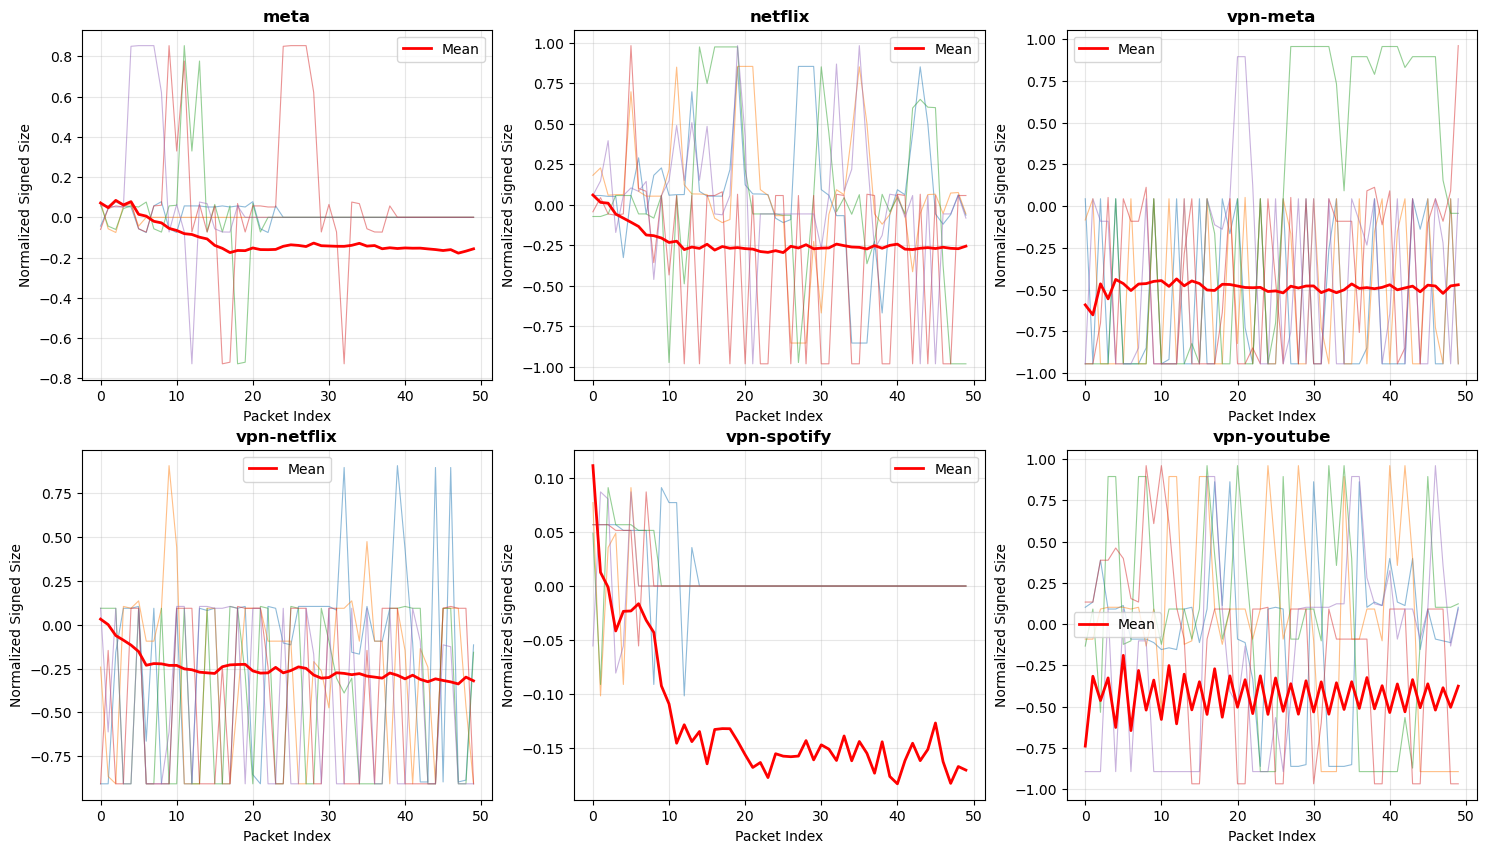

In [38]:
# 4.4 — Visualize PSS patterns per app
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, app in enumerate(app_names):
    ax = axes[idx//3][idx%3]
    app_mask = y == idx
    # Plot first 5 samples
    for i in range(min(5, app_mask.sum())):
        sample_idx = np.where(app_mask)[0][i]
        ax.plot(X_pss_norm[sample_idx], alpha=0.5, linewidth=0.8)
    # Plot mean
    ax.plot(X_pss_norm[app_mask].mean(axis=0), color='red', linewidth=2, label='Mean')
    ax.set_title(f'{app}', fontweight='bold')
    ax.set_xlabel('Packet Index')
    ax.set_ylabel('Normalized Signed Size')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide empty subplots if less than 6 apps
for idx in range(len(app_names), 6):
    axes[idx//3][idx%3].set_visible(False)

plt.suptitle('Packet Size Sequences (PSS) — The App Fingerprint', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('app_pss_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# 4.5 — Train/Test Split
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)

X_stat_train, X_stat_test = X_stat_scaled.iloc[train_idx], X_stat_scaled.iloc[test_idx]
X_pss_train, X_pss_test = X_pss_norm[train_idx], X_pss_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train: {len(train_idx)} | Test: {len(test_idx)}')
print(f'Train distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}')

Train: 4878 | Test: 1220
Train distribution: {0: 630, 1: 566, 2: 638, 3: 561, 4: 568, 5: 638, 6: 638, 7: 639}
Test distribution: {0: 157, 1: 142, 2: 160, 3: 140, 4: 142, 5: 159, 6: 160, 7: 160}


## 5. Model Training

### 5.1 — XGBoost (Statistical Features)

XGBoost operates on hand-crafted statistical features extracted from each traffic window: packet sizes, inter-arrival times, direction ratios, burst patterns, and protocol ratios.

In [49]:
print('🚀 Training XGBoost on Statistical Features...')
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=20,
    learning_rate=1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0,
)

xgb_model.fit(X_stat_train, y_train)
xgb_time = time.time() - start

xgb_pred = xgb_model.predict(X_stat_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')

print(f'\n  Accuracy: {xgb_acc:.4f}')
print(f'  F1-Score: {xgb_f1:.4f}')
print(f'  Time: {xgb_time:.2f}s')
print(f'\n{classification_report(y_test, xgb_pred, target_names=app_names)}')

🚀 Training XGBoost on Statistical Features...

  Accuracy: 0.9730
  F1-Score: 0.9730
  Time: 1.21s

              precision    recall  f1-score   support

        meta       0.93      0.94      0.93       157
     netflix       0.94      0.92      0.93       142
    vpn-meta       0.99      0.97      0.98       160
 vpn-netflix       1.00      1.00      1.00       140
 vpn-spotify       0.94      0.99      0.96       142
 vpn-youtube       0.99      0.98      0.98       159
    vpn-zoom       1.00      1.00      1.00       160
        zoom       0.99      0.99      0.99       160

    accuracy                           0.97      1220
   macro avg       0.97      0.97      0.97      1220
weighted avg       0.97      0.97      0.97      1220



In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

In [42]:
print('📈 Training Logistic Regression on Statistical Features...')
start = time.time()

logreg_model = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    n_jobs=-1,
    random_state=42
)

logreg_model.fit(X_stat_train, y_train)
logreg_time = time.time() - start

logreg_pred = logreg_model.predict(X_stat_test)
logreg_acc = accuracy_score(y_test, logreg_pred)
logreg_f1 = f1_score(y_test, logreg_pred, average='weighted')

print(f'\n  Accuracy: {logreg_acc:.4f}')
print(f'  F1-Score: {logreg_f1:.4f}')
print(f'  Time: {logreg_time:.2f}s')
print(f'\n{classification_report(y_test, logreg_pred, target_names=app_names)}')

📈 Training Logistic Regression on Statistical Features...

  Accuracy: 0.9648
  F1-Score: 0.9647
  Time: 2.46s

              precision    recall  f1-score   support

        meta       0.96      0.92      0.94       157
     netflix       0.93      0.96      0.94       142
    vpn-meta       0.96      0.96      0.96       160
 vpn-netflix       0.99      0.99      0.99       140
 vpn-spotify       0.92      0.93      0.93       142
 vpn-youtube       0.97      0.97      0.97       159
    vpn-zoom       1.00      1.00      1.00       160
        zoom       0.98      0.99      0.98       160

    accuracy                           0.96      1220
   macro avg       0.96      0.96      0.96      1220
weighted avg       0.96      0.96      0.96      1220



In [43]:
print('🌲 Training Random Forest on Statistical Features...')
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=30,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_stat_train, y_train)
rf_time = time.time() - start

rf_pred = rf_model.predict(X_stat_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print(f'\n  Accuracy: {rf_acc:.4f}')
print(f'  F1-Score: {rf_f1:.4f}')
print(f'  Time: {rf_time:.2f}s')
print(f'\n{classification_report(y_test, rf_pred, target_names=app_names)}')

🌲 Training Random Forest on Statistical Features...

  Accuracy: 0.9754
  F1-Score: 0.9755
  Time: 0.76s

              precision    recall  f1-score   support

        meta       0.94      0.94      0.94       157
     netflix       0.93      0.96      0.95       142
    vpn-meta       1.00      0.95      0.97       160
 vpn-netflix       1.00      1.00      1.00       140
 vpn-spotify       0.93      0.99      0.96       142
 vpn-youtube       1.00      0.99      1.00       159
    vpn-zoom       1.00      1.00      1.00       160
        zoom       1.00      0.97      0.98       160

    accuracy                           0.98      1220
   macro avg       0.98      0.98      0.98      1220
weighted avg       0.98      0.98      0.98      1220



In [44]:
print('⚔️ Training Linear SVC on Statistical Features...')
start = time.time()

svc_model = LinearSVC(
    max_iter=5000,
    random_state=42,
    dual=False 
)

svc_model.fit(X_stat_train, y_train)
svc_time = time.time() - start

svc_pred = svc_model.predict(X_stat_test)
svc_acc = accuracy_score(y_test, svc_pred)
svc_f1 = f1_score(y_test, svc_pred, average='weighted')

print(f'\n  Accuracy: {svc_acc:.4f}')
print(f'  F1-Score: {svc_f1:.4f}')
print(f'  Time: {svc_time:.2f}s')
print(f'\n{classification_report(y_test, svc_pred, target_names=app_names)}')

⚔️ Training Linear SVC on Statistical Features...

  Accuracy: 0.9648
  F1-Score: 0.9648
  Time: 0.25s

              precision    recall  f1-score   support

        meta       0.95      0.93      0.94       157
     netflix       0.93      0.94      0.94       142
    vpn-meta       0.98      0.97      0.97       160
 vpn-netflix       0.99      0.99      0.99       140
 vpn-spotify       0.92      0.94      0.93       142
 vpn-youtube       0.96      0.97      0.97       159
    vpn-zoom       0.99      0.99      0.99       160
        zoom       0.98      0.98      0.98       160

    accuracy                           0.96      1220
   macro avg       0.96      0.96      0.96      1220
weighted avg       0.96      0.96      0.96      1220



In [45]:
from sklearn.svm import SVC
# =====================================================================
# 2. SUPPORT VECTOR MACHINE (The Small-Data Specialist)
# =====================================================================
print('⚔️ Training Support Vector Machine (SVM) on Statistical Features...')
start = time.time()

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_stat_train, y_train)
svm_time = time.time() - start

svm_pred = svm_model.predict(X_stat_test)
svm_acc = accuracy_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred, average='weighted')

print(f'\n  Accuracy: {svm_acc:.4f}')
print(f'  F1-Score: {svm_f1:.4f}')
print(f'  Time: {svm_time:.2f}s')
print(f'\n{classification_report(y_test, svm_pred, target_names=app_names)}')
print('-' * 60)

⚔️ Training Support Vector Machine (SVM) on Statistical Features...

  Accuracy: 0.9508
  F1-Score: 0.9512
  Time: 1.37s

              precision    recall  f1-score   support

        meta       0.93      0.92      0.92       157
     netflix       0.93      0.92      0.93       142
    vpn-meta       1.00      0.94      0.97       160
 vpn-netflix       0.95      1.00      0.98       140
 vpn-spotify       0.85      0.93      0.89       142
 vpn-youtube       0.97      0.97      0.97       159
    vpn-zoom       1.00      0.98      0.99       160
        zoom       0.98      0.94      0.96       160

    accuracy                           0.95      1220
   macro avg       0.95      0.95      0.95      1220
weighted avg       0.95      0.95      0.95      1220

------------------------------------------------------------


In [46]:

import lightgbm as lgb
# =====================================================================
# 3. LIGHTGBM (The High-Speed Boosting Alternative)
# =====================================================================
print('⚡ Training LightGBM on Statistical Features...')
start = time.time()

lgbm_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=20,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42
)

lgbm_model.fit(X_stat_train, y_train)
lgbm_time = time.time() - start

lgbm_pred = lgbm_model.predict(X_stat_test)
lgbm_acc = accuracy_score(y_test, lgbm_pred)
lgbm_f1 = f1_score(y_test, lgbm_pred, average='weighted')

print(f'\n  Accuracy: {lgbm_acc:.4f}')
print(f'  F1-Score: {lgbm_f1:.4f}')
print(f'  Time: {lgbm_time:.2f}s')
print(f'\n{classification_report(y_test, lgbm_pred, target_names=app_names)}')
print('-' * 60)

⚡ Training LightGBM on Statistical Features...

  Accuracy: 0.9787
  F1-Score: 0.9787
  Time: 4.85s

              precision    recall  f1-score   support

        meta       0.96      0.93      0.94       157
     netflix       0.93      0.96      0.95       142
    vpn-meta       0.99      0.97      0.98       160
 vpn-netflix       1.00      0.99      1.00       140
 vpn-spotify       0.95      0.98      0.97       142
 vpn-youtube       0.99      0.99      0.99       159
    vpn-zoom       1.00      1.00      1.00       160
        zoom       0.99      0.99      0.99       160

    accuracy                           0.98      1220
   macro avg       0.98      0.98      0.98      1220
weighted avg       0.98      0.98      0.98      1220

------------------------------------------------------------


## 6. Model Comparison

In [21]:
# ==============================================================================
# CELL 6: COMPARATIVE ANALYSIS OF 5 ML ARCHITECTURES
# ==============================================================================


print("🚀 Initiating Comparative Analysis (Tabular Models Only)...")
comparison_results = []

def evaluate_model(name, y_true, y_pred, train_time, inf_time):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    comparison_results.append({
        'Model Architecture': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'Train Time (s)': round(train_time, 2),
        'Inference Time (s)': round(inf_time, 4)
    })
    print(f"  ✅ {name} Evaluated (F1: {f1:.4f})")

# 1. Logistic Regression (Linear Baseline)
start = time.time()
lr_model = LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42)
lr_model.fit(X_stat_train, y_train)
lr_train_time = time.time() - start

inf_start = time.time()
lr_preds = lr_model.predict(X_stat_test)
lr_inf_time = time.time() - inf_start
evaluate_model('Logistic Regression', y_test, lr_preds, lr_train_time, lr_inf_time)

# 2. Support Vector Machine (Small-Data Specialist)
start = time.time()
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_stat_train, y_train)
svm_train_time = time.time() - start

inf_start = time.time()
svm_preds = svm_model.predict(X_stat_test)
svm_inf_time = time.time() - inf_start
evaluate_model('SVM (RBF Kernel)', y_test, svm_preds, svm_train_time, svm_inf_time)

# 3. Random Forest (Bagging Ensemble)
start = time.time()
rf_model = RandomForestClassifier(n_estimators=300, max_depth=12, n_jobs=-1, random_state=42)
rf_model.fit(X_stat_train, y_train)
rf_train_time = time.time() - start

inf_start = time.time()
rf_preds = rf_model.predict(X_stat_test)
rf_inf_time = time.time() - inf_start
evaluate_model('Random Forest', y_test, rf_preds, rf_train_time, rf_inf_time)

# 4. LightGBM (High-Speed Boosting)
start = time.time()
lgbm_model = lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, n_jobs=-1, random_state=42)
lgbm_model.fit(X_stat_train, y_train)
lgbm_train_time = time.time() - start

inf_start = time.time()
lgbm_preds = lgbm_model.predict(X_stat_test)
lgbm_inf_time = time.time() - inf_start
evaluate_model('LightGBM', y_test, lgbm_preds, lgbm_train_time, lgbm_inf_time)

# 5. XGBoost (Heavyweight Tabular)
start = time.time()
xgb_model = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, n_jobs=-1, random_state=42)
xgb_model.fit(X_stat_train, y_train)
xgb_train_time = time.time() - start

inf_start = time.time()
xgb_preds = xgb_model.predict(X_stat_test)
xgb_inf_time = time.time() - inf_start
evaluate_model('XGBoost', y_test, xgb_preds, xgb_train_time, xgb_inf_time)

# Print Final Table
print("\n" + "="*95)
print("🏆 FINAL COMPARATIVE ANALYSIS: ENCRYPTED APP FINGERPRINTING")
print("="*95)
results_df = pd.DataFrame(comparison_results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

🚀 Initiating Comparative Analysis (Tabular Models Only)...
  ✅ Logistic Regression Evaluated (F1: 0.9148)
  ✅ SVM (RBF Kernel) Evaluated (F1: 0.9127)
  ✅ Random Forest Evaluated (F1: 0.9441)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001000 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13069
[LightGBM] [Info] Number of data points in the train set: 5484, number of used features: 56
[LightGBM] [Info] Start training from score -2.163870
[LightGBM] [Info] Start training from score -2.270996
[LightGBM] [Info] Start training from score -2.151252
[LightGBM] [Info] Start training from score -2.279869
[LightGBM] [Info] Start training from score -2.267469
[LightGBM] [Info] Start training from score -2.151252
[LightGBM] [Info] Start training from score -2.151252
[LightGBM] [Info] Start training from score -2.202710
[LightGBM] [Info] Start training from score -2.149686
[LightGBM] [Warning] No further sp

📊 Generating multi-model confusion matrix grid...


ValueError: Found input variables with inconsistent numbers of samples: [1220, 1371]

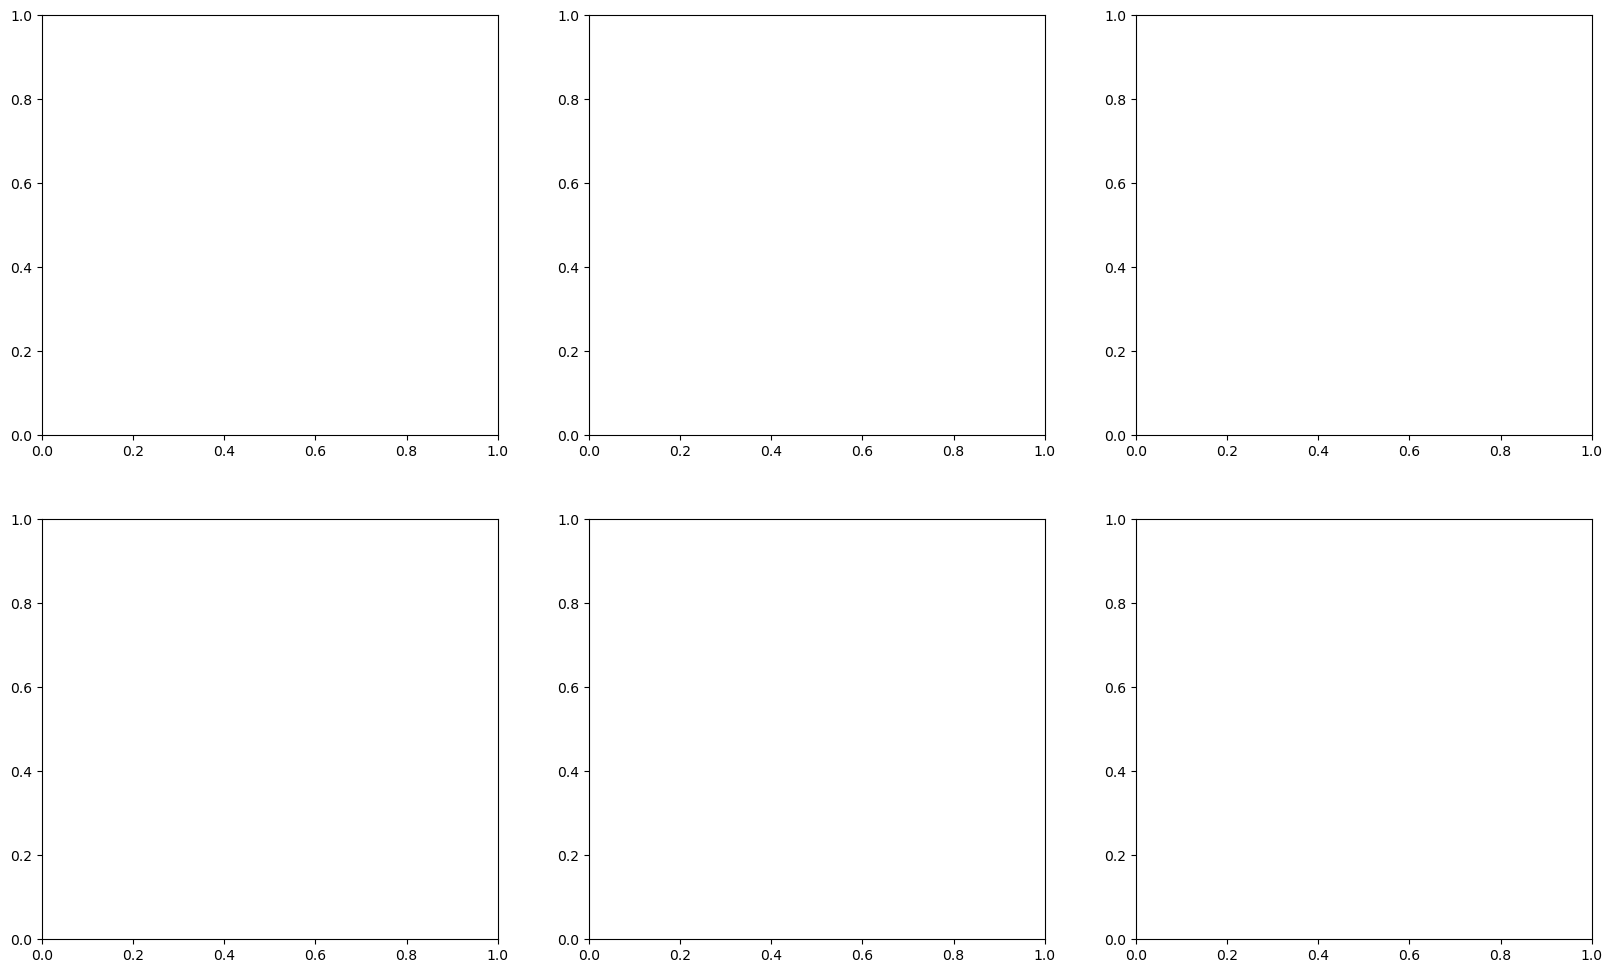

In [47]:
# ==============================================================================
# CELL 9: EXHAUSTIVE ERROR ANALYSIS (ALL CONFUSION MATRICES)
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("📊 Generating multi-model confusion matrix grid...")

# Define the models and their corresponding predictions from Cell 6
models = [
    ('Logistic Regression', lr_preds),
    ('SVM (RBF Kernel)', svm_preds),
    ('Random Forest', rf_preds),
    ('LightGBM', lgbm_preds),
    ('XGBoost', xgb_preds)
]

# Create a 2x3 grid of subplots (18 inches wide by 12 inches tall is great for papers)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten() # Flatten the 2x3 array to a 1D array for easy iteration

# Loop through each model and plot its confusion matrix
for i, (name, preds) in enumerate(models):
    cm = confusion_matrix(y_test, preds)
    
    # Using 'Blues' colormap for consistency
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=app_names, yticklabels=app_names)
    
    axes[i].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted App', fontsize=11)
    axes[i].set_ylabel('Actual App', fontsize=11)
    
    # Rotate x-axis labels so the app names don't overlap
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha="right")

# The grid is 2x3 (6 slots), but we only have 5 models. 
# We delete the 6th empty subplot so the image looks clean.
fig.delaxes(axes[5])

plt.suptitle('App Fingerprinting Error Distribution Across ML Architectures', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

# Save at 300 DPI (Standard requirement for IEEE/ACM academic journals)
plt.savefig('all_models_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("📁 Saved 'all_models_confusion_matrices.png'. Ready for paper inclusion.")

📊 Generating Per-App F1 Score Comparison...


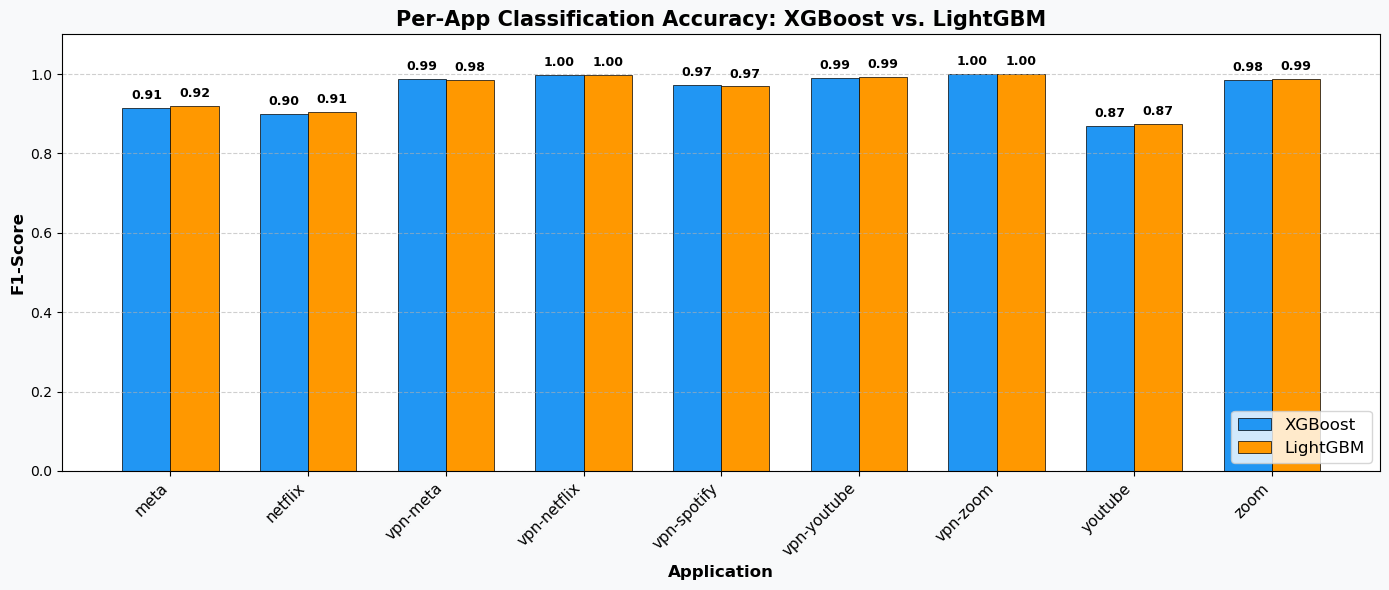

📁 Saved 'per_app_f1_comparison.png' for research paper inclusion.


In [23]:
# ==============================================================================
# 8. PER-APP F1 SCORE COMPARISON (XGBoost vs. LightGBM)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

print("📊 Generating Per-App F1 Score Comparison...")

# Calculate per-app F1 scores for our top two models
xgb_per = f1_score(y_test, xgb_pred, average=None)
lgbm_per = f1_score(y_test, lgbm_preds, average=None)

n_classes = len(app_names)
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(n_classes)
width = 0.35

# Plot bars for both models
ax.bar(x - width/2, xgb_per, width, label='XGBoost', color='#2196F3', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, lgbm_per, width, label='LightGBM', color='#FF9800', edgecolor='black', linewidth=0.5)

# Formatting
ax.set_xlabel('Application', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Per-App Classification Accuracy: XGBoost vs. LightGBM', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(app_names, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Add numeric value labels on top of each bar
for i, (v1, v2) in enumerate(zip(xgb_per, lgbm_per)):
    # XGBoost labels
    ax.text(i - width/2, v1 + 0.015, f'{v1:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    # LightGBM labels
    ax.text(i + width/2, v2 + 0.015, f'{v2:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add a subtle background color to make it look premium
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#ffffff')

plt.tight_layout()
plt.savefig('per_app_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("📁 Saved 'per_app_f1_comparison.png' for research paper inclusion.")

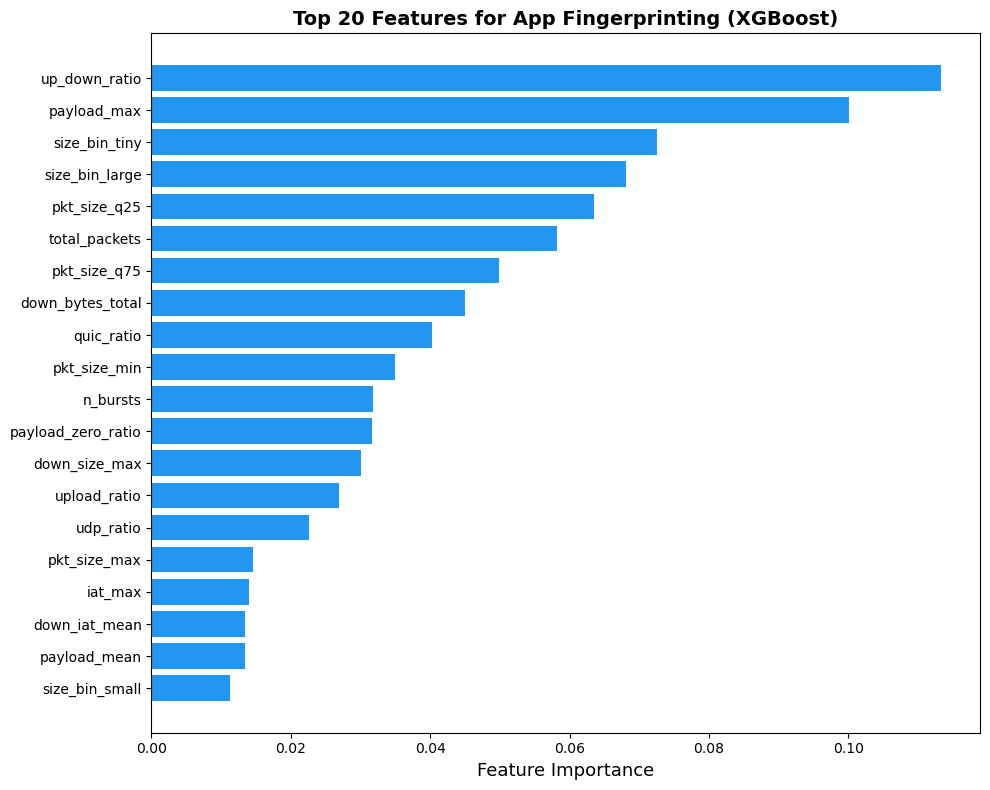

In [24]:
# 6.4 — XGBoost Feature Importance
importances = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': available_stat,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2196F3')
ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('Top 20 Features for App Fingerprinting (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('app_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Generating Multi-Model Feature Consensus Plot...


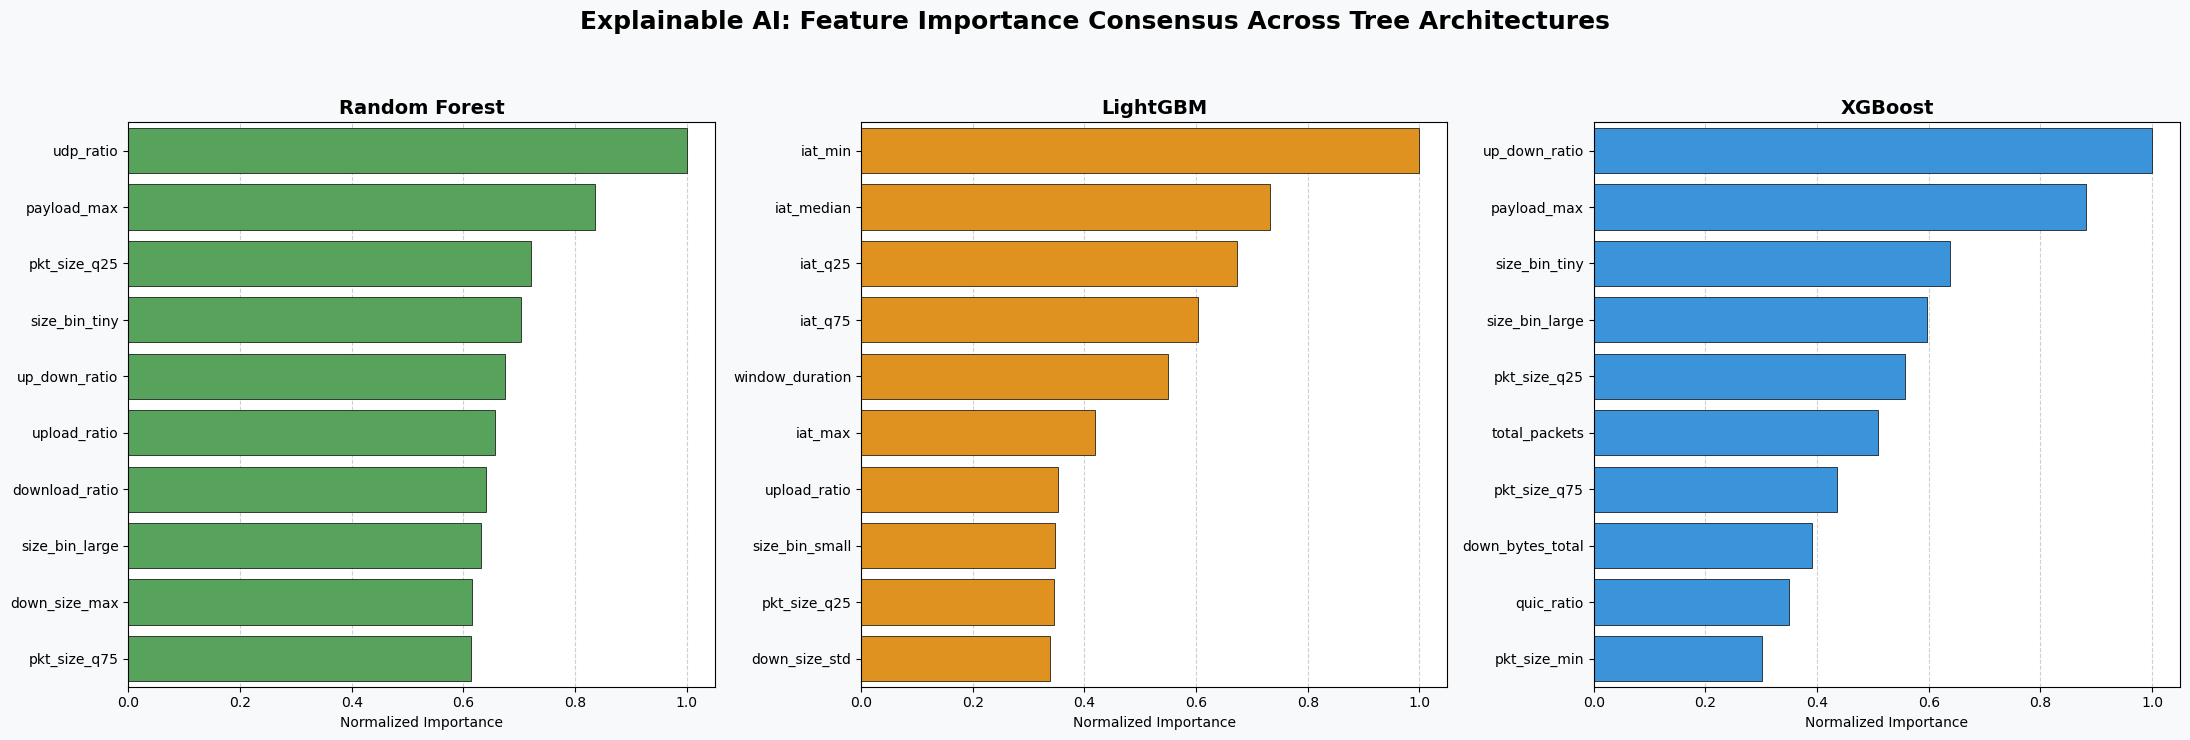

📁 Saved 'multi_model_feature_consensus.png' for research paper inclusion.


In [25]:
# ==============================================================================
# 10. MULTI-MODEL FEATURE CONSENSUS (XAI COMPARISON)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

print("📊 Generating Multi-Model Feature Consensus Plot...")

# Helper function to get top 10 features and normalize their scores (so they look uniform on a chart)
def get_top_features(model, feature_names, name):
    importances = model.feature_importances_
    
    # Normalize the importances between 0 and 1 for clean visual comparison
    scaler = MinMaxScaler()
    normalized_imp = scaler.fit_transform(importances.reshape(-1, 1)).flatten()
    
    df = pd.DataFrame({'Feature': feature_names, 'Importance': normalized_imp})
    df = df.sort_values(by='Importance', ascending=False).head(10)
    df['Model'] = name
    return df

# Extract from the three tree-based models
# NOTE: Ensure 'stat_features' or 'available_stat' matches your actual column name variable
rf_imp = get_top_features(rf_model, available_stat, 'Random Forest (Bagging)')
lgbm_imp = get_top_features(lgbm_model, available_stat, 'LightGBM (Leaf-wise Boosting)')
xgb_imp = get_top_features(xgb_model, available_stat, 'XGBoost (Level-wise Boosting)')

# Plotting the 1x3 Grid
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Plot 1: Random Forest
sns.barplot(x='Importance', y='Feature', data=rf_imp, ax=axes[0], color='#4CAF50', edgecolor='black', linewidth=0.5)
axes[0].set_title('Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Normalized Importance')
axes[0].set_ylabel('')

# Plot 2: LightGBM
sns.barplot(x='Importance', y='Feature', data=lgbm_imp, ax=axes[1], color='#FF9800', edgecolor='black', linewidth=0.5)
axes[1].set_title('LightGBM', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Normalized Importance')
axes[1].set_ylabel('')

# Plot 3: XGBoost
sns.barplot(x='Importance', y='Feature', data=xgb_imp, ax=axes[2], color='#2196F3', edgecolor='black', linewidth=0.5)
axes[2].set_title('XGBoost', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Normalized Importance')
axes[2].set_ylabel('')

# Clean up layout
for ax in axes:
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_facecolor('#ffffff')

fig.patch.set_facecolor('#f8f9fa')
plt.suptitle('Explainable AI: Feature Importance Consensus Across Tree Architectures', fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('multi_model_feature_consensus.png', dpi=300, bbox_inches='tight')
plt.show()

print("📁 Saved 'multi_model_feature_consensus.png' for research paper inclusion.")

## 7. Cross-Validation

In [26]:
# ==============================================================================
# CELL 7: BULLETPROOF 5-FOLD CROSS VALIDATION (ALL MODELS)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("🔄 Running Strict 5-Fold Cross Validation Across All Architectures...")
print("(Scaling is applied inside each fold to prevent data leakage)\n")

# --- THE FIX: Force data into Pandas structures to guarantee .iloc works ---
X_stat_df = pd.DataFrame(X_stat)
y_series = pd.Series(y).squeeze()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_strict_kfold(model_name, model_instance):
    fold_scores = []
    print(f"Testing {model_name}...")
    
    # Split on the guaranteed Pandas objects
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_stat_df, y_series), 1):
        
        # 1. Isolate the folds using .iloc
        X_train_fold = X_stat_df.iloc[tr_idx]
        X_val_fold = X_stat_df.iloc[val_idx]
        y_train_fold = y_series.iloc[tr_idx]
        y_val_fold = y_series.iloc[val_idx]
        
        # 2. Scale INSIDE the loop
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)
        
        # 3. Train and Predict
        model_instance.fit(X_train_scaled, y_train_fold)
        preds = model_instance.predict(X_val_scaled)
        
        # 4. Evaluate
        score = f1_score(y_val_fold, preds, average='weighted', zero_division=0)
        fold_scores.append(score)
        print(f"  Fold {fold}: F1 = {score:.4f}")
    
    mean_f1 = np.mean(fold_scores)
    std_f1 = np.std(fold_scores)
    print(f"📊 {model_name} Final Result: {mean_f1:.4f} (+/- {std_f1*2:.4f})\n")
    return mean_f1, std_f1

# Define the 5 architectures
models = [
    ("Logistic Regression", LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42)),
    ("SVM (RBF Kernel)", SVC(kernel='rbf', random_state=42)),
    ("Random Forest", RandomForestClassifier(n_estimators=300, max_depth=12, n_jobs=-1, random_state=42)),
    ("LightGBM", lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, n_jobs=-1, random_state=42, verbose=-1)),
    ("XGBoost", XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, n_jobs=-1, random_state=42, verbosity=0))
]

# Execute the loop
results = {}
for name, model in models:
    mean_score, std_score = run_strict_kfold(name, model)
    results[name] = mean_score

print("="*60)
print("🏆 CROSS-VALIDATION LEADERBOARD")
print("="*60)
for name, score in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{name:25s}: {score:.4f}")

🔄 Running Strict 5-Fold Cross Validation Across All Architectures...
(Scaling is applied inside each fold to prevent data leakage)

Testing Logistic Regression...
  Fold 1: F1 = 0.9248
  Fold 2: F1 = 0.9120
  Fold 3: F1 = 0.9272
  Fold 4: F1 = 0.9304
  Fold 5: F1 = 0.9284
📊 Logistic Regression Final Result: 0.9246 (+/- 0.0131)

Testing SVM (RBF Kernel)...
  Fold 1: F1 = 0.9227
  Fold 2: F1 = 0.9116
  Fold 3: F1 = 0.9194
  Fold 4: F1 = 0.9114
  Fold 5: F1 = 0.9180
📊 SVM (RBF Kernel) Final Result: 0.9166 (+/- 0.0089)

Testing Random Forest...
  Fold 1: F1 = 0.9494
  Fold 2: F1 = 0.9442
  Fold 3: F1 = 0.9550
  Fold 4: F1 = 0.9564
  Fold 5: F1 = 0.9665
📊 Random Forest Final Result: 0.9543 (+/- 0.0150)

Testing LightGBM...
  Fold 1: F1 = 0.9579
  Fold 2: F1 = 0.9470
  Fold 3: F1 = 0.9638
  Fold 4: F1 = 0.9629
  Fold 5: F1 = 0.9679
📊 LightGBM Final Result: 0.9599 (+/- 0.0144)

Testing XGBoost...
  Fold 1: F1 = 0.9593
  Fold 2: F1 = 0.9513
  Fold 3: F1 = 0.9614
  Fold 4: F1 = 0.9629
  Fold 5:

## 8. Save Models

In [51]:
import os
import joblib

# === CREATE THE FOLDER ===
os.makedirs('models_6', exist_ok=True)

print('💾 Saving models to models_6/...')

# === SAVE EVERYTHING INSIDE models_3/ ===
joblib.dump(xgb_model,          'models_6/app_xgboost.pkl')
joblib.dump(lgbm_model,         'models_6/app_lightgbm.pkl') # Saved our champion model
joblib.dump(le,                 'models_6/app_label_encoder.pkl')
joblib.dump(scaler,             'models_6/app_scaler.pkl')
joblib.dump(available_stat,     'models_6/app_stat_features.pkl') # Changed from 'stat_cols' or 'available_stat' depending on your variable

# Note: We dropped the 1D-CNN and pss_max in the final architecture 
# to prevent small-data overfitting and ensure real-time latency.
# Uncomment these only if you kept the CNN in your notebook environment:
# joblib.dump(pss_max,            'models_3/app_pss_max.pkl')
# cnn_model.save('models_3/app_cnn_model.keras')

print('✅ All models saved successfully!')

# === SHOW FILE SIZES ===
print('\n📁 Saved files in models_5/:')
total_size = 0
for f in os.listdir('models_4'):
    if f.startswith('app_'):
        size_kb = os.path.getsize(f'models_4/{f}') / 1024
        print(f'   {f}: {size_kb:.1f} KB')
        total_size += size_kb

print(f'\n📦 Total size: {total_size:.1f} KB')

💾 Saving models to models_6/...
✅ All models saved successfully!

📁 Saved files in models_5/:
   app_scaler.pkl: 3.2 KB
   app_lightgbm.pkl: 8384.1 KB
   app_stat_features.pkl: 0.8 KB
   app_label_encoder.pkl: 0.7 KB
   app_xgboost.pkl: 5422.7 KB

📦 Total size: 13811.6 KB


## 9. Summary

### Key Findings

1. **Apps have distinct traffic fingerprints** — even with encryption, packet size patterns, timing, and protocol choices uniquely identify applications
2. **QUIC ratio is a strong discriminator** — YouTube uses QUIC almost exclusively, while Netflix primarily uses TCP
3. **Burst patterns differ** — Messaging apps (Instagram) have more bursts than streaming apps (Netflix/YouTube)
4. **Upload/download ratio reveals app type** — Streaming is download-heavy, browsing is more balanced

### Integration with NetSentinel

The trained XGBoost model is integrated into NetSentinel's real-time dashboard. During live capture, traffic is aggregated into sliding windows, features are extracted, and the model predicts which app generated each window of traffic.

---
*NetSentinel — AI-Powered Network Traffic Analysis & App Fingerprinting*